In [ ]:
# Linear Regression with One Variable - Comprehensive Study Notebook
# Execute this cell to set up the notebook environment

!pip install numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Linear Regression with One Variable

## 1. Executive Summary

This notebook covers the foundational concepts of linear regression with one variable, the simplest and most widely used supervised learning algorithm. Linear regression models the relationship between a single input feature (x) and a continuous output target (y) by fitting a straight line to the training data. The core objective is to learn the optimal parameters (slope w and intercept b) that minimize the difference between predictions and actual values.

The lecture introduces the complete machine learning workflow: from data representation and model definition to cost function formulation and parameter optimization. You'll learn how to represent training data, define a linear model f(x) = wx + b, measure model performance using the squared error cost function J(w,b), and understand how different parameter choices affect both the model's predictions and the corresponding cost. These concepts form the foundation for all subsequent machine learning algorithms you'll encounter.

Learning objectives:
- Understand supervised learning terminology: training set, features, targets, parameters
- Implement the linear regression model $f(x) = wx + b$
- Calculate and interpret the squared error cost function $J(w,b)$
- Visualize how parameters w and b affect both the model line and the cost function
- Grasp the optimization goal: minimize $J(w,b)$ to find the best-fit line

## 2. Key Concepts & Glossary

| Term | Definition |
|------|------------|
| **Supervised Learning** | Training a model using labeled data with both input features and correct output targets |
| **Training Set** | The dataset used to train the model, containing m examples of (input, output) pairs |
| **Feature (x)** | Input variable used to make predictions (e.g., house size in square feet) |
| **Target (y)** | Output variable being predicted, the "right answer" in the training data |
| **Model (f)** | Function that maps input x to prediction ŷ; in linear regression: f(x) = wx + b |
| **Parameters** | Variables w and b that the model learns during training; also called coefficients or weights |
| **Prediction (ŷ)** | The model's estimated output value for a given input, pronounced "y-hat" |
| **Cost Function (J)** | Measures how well the model fits the training data by averaging squared errors |
| **Squared Error** | (ŷ - y)², the squared difference between prediction and actual target |
| **Linear Regression** | A regression model that predicts a continuous output using a linear combination of inputs |
| **Univariate** | "One variable" - refers to linear regression with a single input feature |
| **Slope (w)** | Parameter controlling the steepness of the regression line |
| **Intercept (b)** | Parameter controlling where the line crosses the vertical axis (y-intercept) |
| **Minimization** | The process of finding parameter values that yield the smallest possible cost |
| **Contour Plot** | 2D visualization showing lines of equal cost for different (w,b) combinations |

## 3. Important Data Points

### Key Formulas

| Formula | Description |
|---------|-------------|
| $f_{w,b}(x) = wx + b$ | Linear regression model with one variable |
| $J(w,b) = \frac{1}{2m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$ | Squared error cost function |
| $ŷ^{(i)} = f_{w,b}(x^{(i)})$ | Prediction for the i-th training example |
| m = number of training examples | Dataset size notation |
| $(x^{(i)}, y^{(i)})$ | i-th training example (superscript denotes index, not exponent) |

### Dataset Statistics (Portland Housing Example)

| Metric | Value |
|--------|-------|
| Training examples (m) | 47 |
| Input feature (x) | House size (sq ft) |
| Output target (y) | Price (\$1000s) |
|Sample house size |2,104 sq ft|
|Sample price | \$400,000|



## 4. Core Concepts

### 4.1 The Training Set and Notation

In supervised learning, we begin with a **training set**: historical data containing both inputs and their corresponding correct outputs. For housing price prediction, each training example consists of a house size (x) and the price it actually sold for (y). The notation system used throughout machine learning is standardized:

- **x**: Input variable or feature (e.g., house size)
- **y**: Output variable or target (e.g., price)
- **m**: Number of training examples in the dataset
- **$(x, y)$**: A single training example
- **$(x^{(i)}, y^{(i)})$**: The i-th training example (superscript i is an index, not exponent)

This notation allows us to precisely reference specific data points and build mathematical formulations that scale to any dataset size.

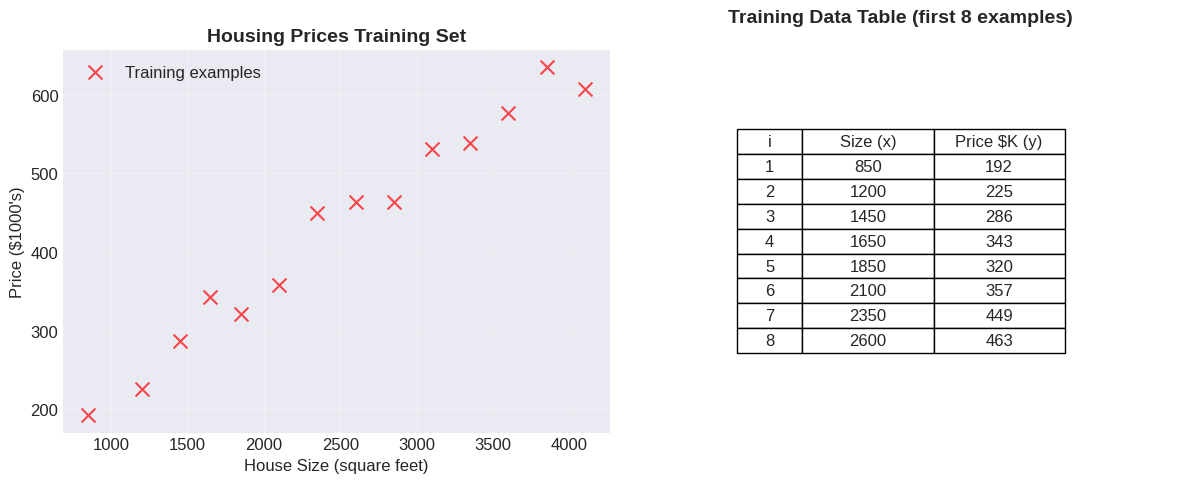

Total training examples (m) = 14
Example: x¹ = 850 sq ft, y¹ = $192K


In [ ]:
# Visualizing the Training Set
# Create synthetic housing data similar to the Portland dataset
np.random.seed(42)
house_sizes = np.array([850, 1200, 1450, 1650, 1850, 2100, 2350,
                        2600, 2850, 3100, 3350, 3600, 3850, 4100])
prices = 0.15 * house_sizes + 50 + np.random.normal(0, 30, len(house_sizes))
prices = np.maximum(prices, 0)  # Ensure non-negative prices

plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot of training data
plt.subplot(1, 2, 1)
plt.scatter(house_sizes, prices, color='red', marker='x', s=100, alpha=0.7, label='Training examples')
plt.xlabel('House Size (square feet)', fontsize=12)
plt.ylabel('Price ($1000\'s)', fontsize=12)
plt.title('Housing Prices Training Set', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Data table visualization
plt.subplot(1, 2, 2)
plt.axis('off')
table_data = [[f"{i+1}", f"{int(house_sizes[i])}", f"{int(prices[i])}"]
              for i in range(min(8, len(house_sizes)))]
table = plt.table(cellText=table_data,
                  colLabels=['i', 'Size (x)', 'Price $K (y)'],
                  cellLoc='center', loc='center',
                  colWidths=[0.1, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
plt.title('Training Data Table (first 8 examples)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print(f"Total training examples (m) = {len(house_sizes)}")
print(f"Example: x¹ = {house_sizes[0]:.0f} sq ft, y¹ = ${prices[0]:.0f}K")

### 4.2 The Linear Regression Model

The linear regression model represents the relationship between input x and output y as a straight line:

**$$f_{w,b}(x) = wx + b$$**

Where:
- **$w$** (slope) controls how steep the line is
- **$b$** (intercept) determines where the line crosses the y-axis
- **$f_{w,b}(x)$** is the predicted value $(ŷ)$ for input $x$

This is called **univariate linear regression** because there's only one input variable. Despite its simplicity, this model is incredibly powerful and forms the basis for more complex algorithms like neural networks (where multiple such linear units are combined).

#### Model Predictions

The model produces predictions:

$$\hat{y} = wx + b$$

Where $\hat{y}$ (y-hat) represents the predicted value.

The goal is to make predictions as close as possible to actual values.

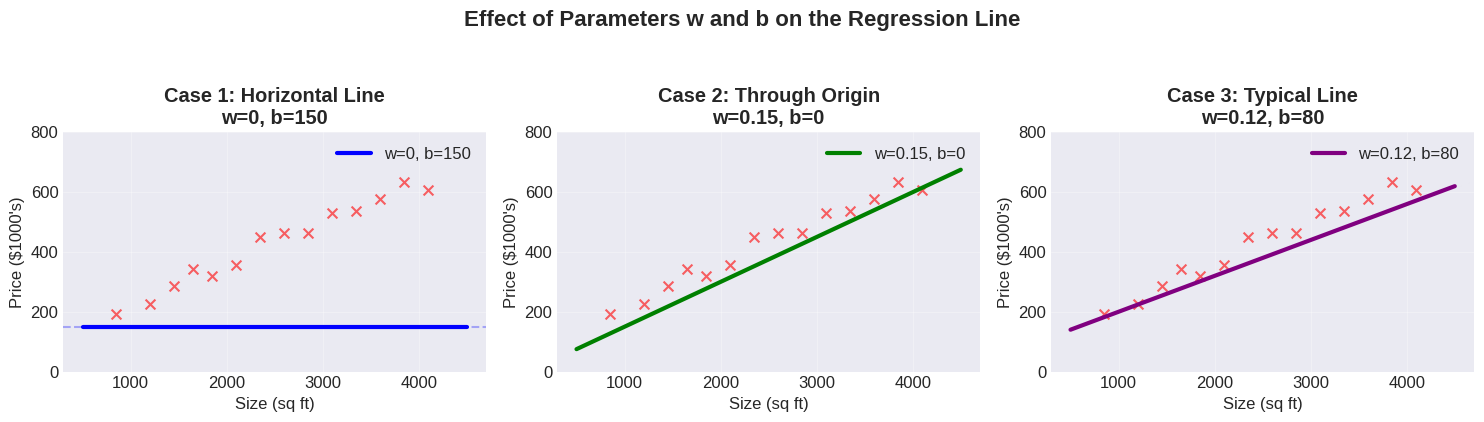

In [ ]:
# Visualizing the effect of parameters w and b
x_line = np.linspace(500, 4500, 100)

plt.figure(figsize=(15, 4))

# Case 1: w = 0, b = 1.5 (horizontal line)
plt.subplot(1, 3, 1)
plt.scatter(house_sizes, prices, color='red', marker='x', s=50, alpha=0.6)
w1, b1 = 0, 150
plt.plot(x_line, w1 * x_line + b1, 'b-', linewidth=3, label=f'w={w1}, b={b1}')
plt.axhline(y=b1, color='b', linestyle='--', alpha=0.3)
plt.xlabel('Size (sq ft)')
plt.ylabel('Price ($1000\'s)')
plt.title(f'Case 1: Horizontal Line\nw={w1}, b={b1}', fontweight='bold')
plt.ylim(0, 800)
plt.grid(True, alpha=0.3)
plt.legend()

# Case 2: w = 0.5, b = 0 (through origin)
plt.subplot(1, 3, 2)
plt.scatter(house_sizes, prices, color='red', marker='x', s=50, alpha=0.6)
w2, b2 = 0.15, 0
plt.plot(x_line, w2 * x_line + b2, 'g-', linewidth=3, label=f'w={w2}, b={b2}')
plt.xlabel('Size (sq ft)')
plt.ylabel('Price ($1000\'s)')
plt.title(f'Case 2: Through Origin\nw={w2}, b={b2}', fontweight='bold')
plt.ylim(0, 800)
plt.grid(True, alpha=0.3)
plt.legend()

# Case 3: w = 0.5, b = 1 (typical line)
plt.subplot(1, 3, 3)
plt.scatter(house_sizes, prices, color='red', marker='x', s=50, alpha=0.6)
w3, b3 = 0.12, 80
plt.plot(x_line, w3 * x_line + b3, 'purple', linewidth=3, label=f'w={w3:.2f}, b={b3}')
plt.xlabel('Size (sq ft)')
plt.ylabel('Price ($1000\'s)')
plt.title(f'Case 3: Typical Line\nw={w3:.2f}, b={b3}', fontweight='bold')
plt.ylim(0, 800)
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Effect of Parameters w and b on the Regression Line', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 4.3 The Squared Error Cost Function

The **cost function** measures how well our model fits the training data. For each training example, we compute the **error**: the vertical distance between the prediction (on the line) and the actual target value. The squared error cost function averages these squared differences:

$$J(w,b) = \frac{1}{2m} \sum (prediction - actual)^2$$

**$$J(w,b) = \frac{1}{2m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$**

Key insights about the cost function:

1. **Why square the errors?** - Squares make all errors positive (so they don't cancel), penalize larger errors more heavily, and create a smooth, differentiable function
2. **Why divide by 2m?** - Dividing by m gives the average error (not total), making cost independent of dataset size. The extra division by 2 is a mathematical convenience for later calculus (derivatives become cleaner)
3. **What does J measure?** - A small J means predictions are close to targets (good fit); large J means poor fit

The goal of linear regression is to **minimize J(w,b)** - find the parameter values that make the cost as small as possible.

/tmp/ipykernel_316/3919649636.py:49: UserWarning: Glyph 8305 (\N{SUPERSCRIPT LATIN SMALL LETTER I}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8305 (\N{SUPERSCRIPT LATIN SMALL LETTER I}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


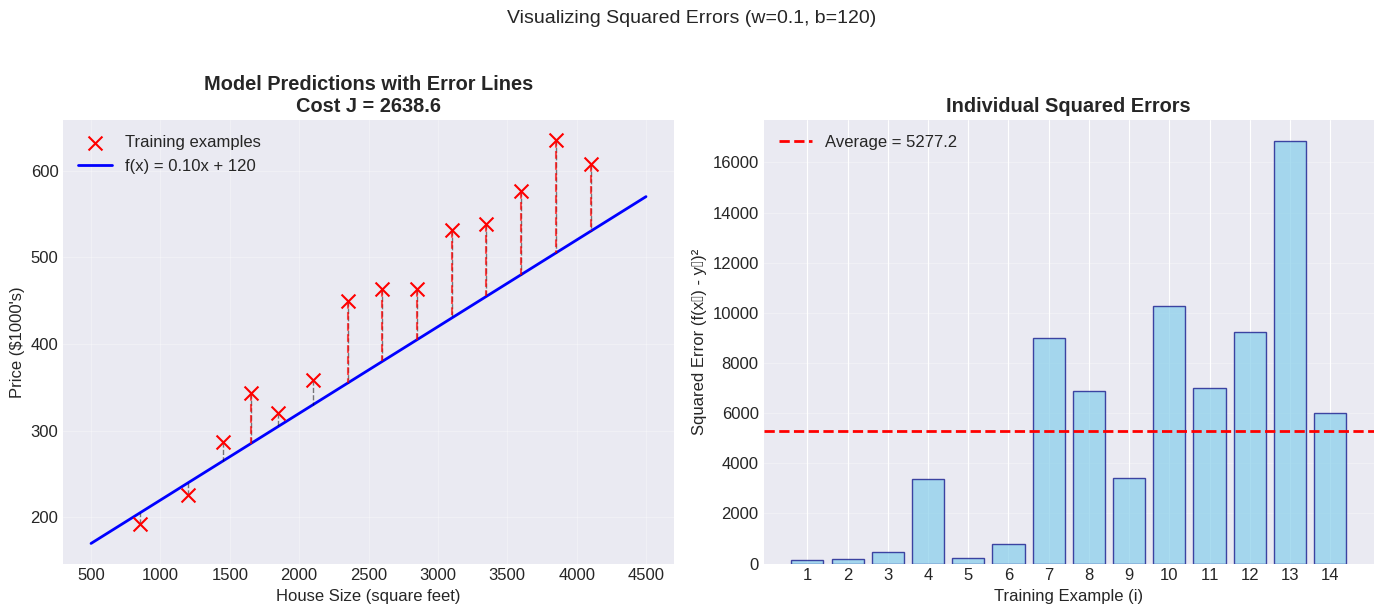

Sum of squared errors = 73881.2
Cost J(w,b) = 1/(2m) * sum = 73881.2 / (2 * 14) = 2638.6


In [ ]:
# Visualizing the squared errors for a given line
# Choose a suboptimal line to clearly show errors
w_test, b_test = 0.1, 120

# Calculate predictions and errors
predictions = w_test * house_sizes + b_test
errors = predictions - prices
squared_errors = errors ** 2
cost = np.sum(squared_errors) / (2 * len(house_sizes))

plt.figure(figsize=(14, 6))

# Plot 1: Data points with regression line and error bars
plt.subplot(1, 2, 1)
plt.scatter(house_sizes, prices, color='red', marker='x', s=100, label='Training examples', zorder=5)
plt.plot(x_line, w_test * x_line + b_test, 'b-', linewidth=2, label=f'f(x) = {w_test:.2f}x + {b_test}')

# Draw error lines for each point
for i, (x, y_true) in enumerate(zip(house_sizes, prices)):
    y_pred = w_test * x + b_test
    plt.plot([x, x], [y_true, y_pred], 'k--', alpha=0.5, linewidth=1)
    # Color code the error lines by magnitude
    if abs(y_pred - y_true) > 50:
        plt.plot([x, x], [y_true, y_pred], 'r--', alpha=0.7, linewidth=1.5)

plt.xlabel('House Size (square feet)', fontsize=12)
plt.ylabel('Price ($1000\'s)', fontsize=12)
plt.title(f'Model Predictions with Error Lines\nCost J = {cost:.1f}', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Individual squared errors
plt.subplot(1, 2, 2)
x_pos = np.arange(len(house_sizes))
plt.bar(x_pos, squared_errors, color='skyblue', edgecolor='navy', alpha=0.7)
plt.xlabel('Training Example (i)', fontsize=12)
plt.ylabel('Squared Error (f(xⁱ) - yⁱ)²', fontsize=12)
plt.title('Individual Squared Errors', fontweight='bold')
plt.xticks(x_pos, [f'{i+1}' for i in x_pos])
plt.grid(True, alpha=0.3, axis='y')

# Add average line
avg_sq_error = np.mean(squared_errors)
plt.axhline(y=avg_sq_error, color='red', linestyle='--', linewidth=2,
            label=f'Average = {avg_sq_error:.1f}')
plt.legend()

plt.suptitle(f'Visualizing Squared Errors (w={w_test}, b={b_test})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Sum of squared errors = {np.sum(squared_errors):.1f}")
print(f"Cost J(w,b) = 1/(2m) * sum = {np.sum(squared_errors):.1f} / (2 * {len(house_sizes)}) = {cost:.1f}")

### 4.4 Simplified Cost Function (b = 0)

To build intuition, let's first consider a simplified model where b = 0, so $f_w(x) = wx$. Now the cost function depends only on w:

**$$J(w) = \frac{1}{2m}\sum_{i=1}^{m} (wx^{(i)} - y^{(i)})^2$$**

By trying different values of w, we can see:
- Each w value produces a different line through the origin
- For each line, we can calculate the cost J(w)
- Plotting J(w) for many w values reveals a U-shaped curve (convex function)
- The minimum of this curve occurs at the optimal w value

This convex shape is crucial - it guarantees that we can find the global minimum using optimization algorithms like gradient descent.

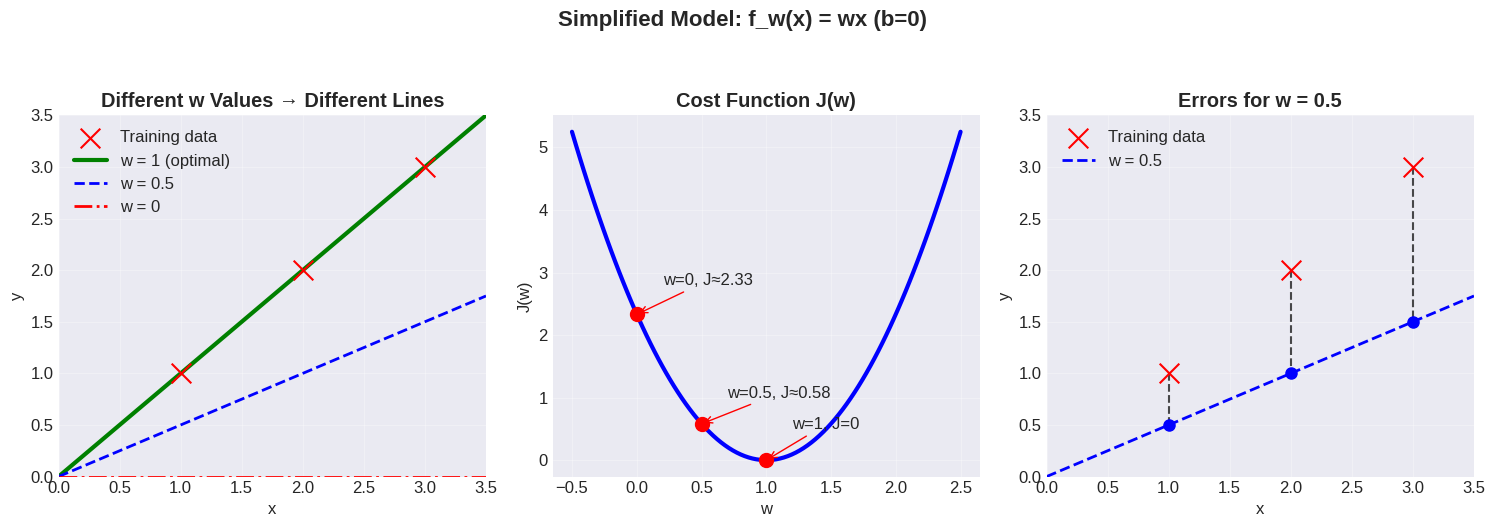

At w = 1:   J = 0 (perfect fit)
At w = 0.5: J = 0.58
At w = 0:   J = 2.4


In [ ]:
# Visualizing the simplified cost function J(w) with b=0
# Create a simple dataset with perfect linear relationship (for clarity)
x_simple = np.array([1, 2, 3])
y_simple = np.array([1, 2, 3])

# Calculate J(w) for many w values
w_values = np.linspace(-0.5, 2.5, 100)
J_values = []

for w in w_values:
    predictions = w * x_simple
    errors = predictions - y_simple
    squared_errors = errors ** 2
    J = np.sum(squared_errors) / (2 * len(x_simple))
    J_values.append(J)

plt.figure(figsize=(15, 5))

# Plot 1: Three different lines for different w values
plt.subplot(1, 3, 1)
plt.scatter(x_simple, y_simple, color='red', marker='x', s=200, label='Training data', zorder=5)

# w = 1 (optimal)
w_opt = 1
x_line = np.linspace(0, 3.5, 100)
plt.plot(x_line, w_opt * x_line, 'g-', linewidth=3, label=f'w = {w_opt} (optimal)')

# w = 0.5 (underestimate)
w_under = 0.5
plt.plot(x_line, w_under * x_line, 'b--', linewidth=2, label=f'w = {w_under}')

# w = 0 (horizontal)
w_zero = 0
plt.plot(x_line, w_zero * x_line, 'r-.', linewidth=2, label=f'w = {w_zero}')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Different w Values → Different Lines', fontweight='bold')
plt.xlim(0, 3.5)
plt.ylim(0, 3.5)
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Cost function J(w)
plt.subplot(1, 3, 2)
plt.plot(w_values, J_values, 'b-', linewidth=3)
plt.scatter([1, 0.5, 0], [0, 0.58, 2.33], color='red', s=100, zorder=5)
plt.xlabel('w', fontsize=12)
plt.ylabel('J(w)', fontsize=12)
plt.title('Cost Function J(w)', fontweight='bold')
plt.grid(True, alpha=0.3)

# Annotate points
plt.annotate('w=1, J=0', xy=(1, 0), xytext=(1.2, 0.5),
             arrowprops=dict(arrowstyle='->', color='red'))
plt.annotate('w=0.5, J≈0.58', xy=(0.5, 0.58), xytext=(0.7, 1.0),
             arrowprops=dict(arrowstyle='->', color='red'))
plt.annotate('w=0, J≈2.33', xy=(0, 2.33), xytext=(0.2, 2.8),
             arrowprops=dict(arrowstyle='->', color='red'))

# Plot 3: Error visualization for w=0.5
plt.subplot(1, 3, 3)
plt.scatter(x_simple, y_simple, color='red', marker='x', s=200, label='Training data', zorder=5)
plt.plot(x_line, 0.5 * x_line, 'b--', linewidth=2, label='w = 0.5')

# Draw error lines
for x, y in zip(x_simple, y_simple):
    y_pred = 0.5 * x
    plt.plot([x, x], [y, y_pred], 'k--', alpha=0.7)
    plt.plot(x, y_pred, 'bo', markersize=8)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Errors for w = 0.5', fontweight='bold')
plt.xlim(0, 3.5)
plt.ylim(0, 3.5)
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Simplified Model: f_w(x) = wx (b=0)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("At w = 1:   J = 0 (perfect fit)")
print("At w = 0.5: J =", J_values[np.argmin(np.abs(w_values - 0.5))].round(2))
print("At w = 0:   J =", J_values[np.argmin(np.abs(w_values - 0))].round(2))

### 4.5 Full Cost Function with Two Parameters

With both parameters w and b, the cost function J(w,b) becomes a 3D surface. Key properties:

1. **Convex shape**: Like a bowl or hammock, ensuring a single global minimum
2. **Contour plots**: 2D slices showing lines of equal cost (ellipses)
3. **Minimum point**: At the bottom center, where the best parameters live

The contour plot is particularly useful:
- Each ellipse connects points with the same cost value
- The center of the smallest ellipse is the minimum
- Moving away from the center increases cost
- The shape of ellipses indicates parameter sensitivity

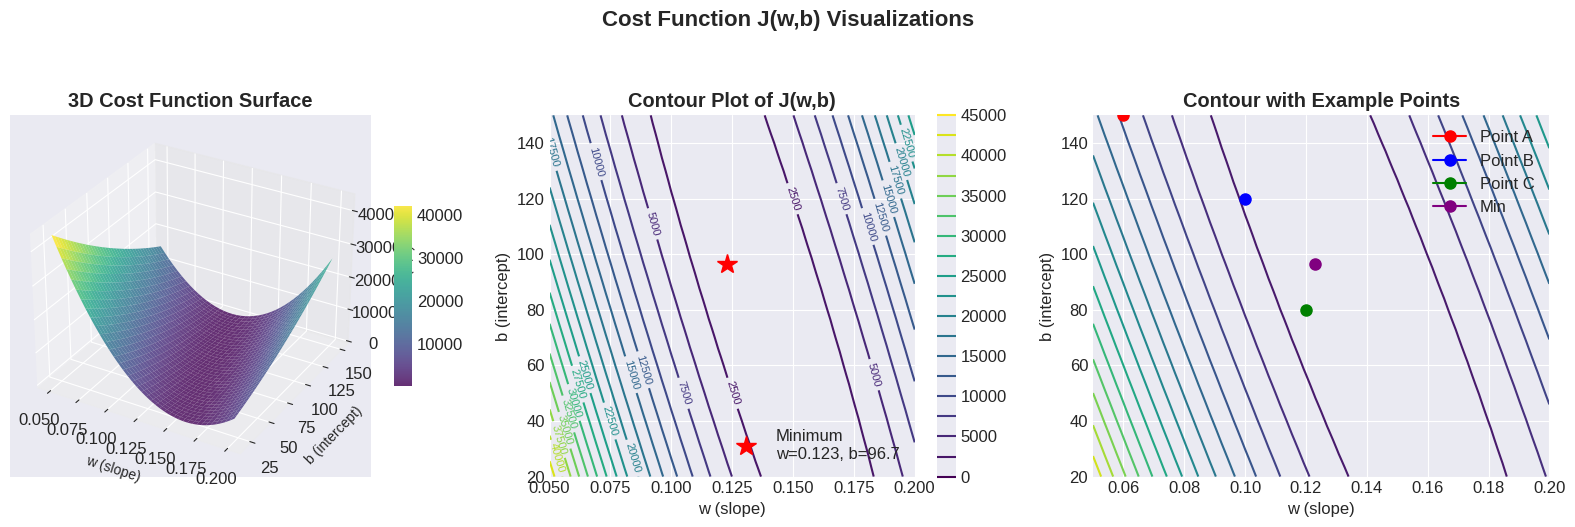

Approximate minimum: w = 0.1231, b = 96.7, J = 257.9


In [ ]:
# Create a 3D visualization of the cost function J(w,b)
# Generate a grid of w and b values
w_range = np.linspace(0.05, 0.2, 40)
b_range = np.linspace(20, 150, 40)
W, B = np.meshgrid(w_range, b_range)

# Calculate cost J for each (w,b) combination
J = np.zeros_like(W)
m = len(house_sizes)

for i in range(len(w_range)):
    for j in range(len(b_range)):
        w_val = W[j, i]  # Note: meshgrid indexing
        b_val = B[j, i]
        predictions = w_val * house_sizes + b_val
        errors = predictions - prices
        squared_errors = errors ** 2
        J[j, i] = np.sum(squared_errors) / (2 * m)

plt.figure(figsize=(16, 5))

# Plot 1: 3D surface
ax1 = plt.subplot(1, 3, 1, projection='3d')
surf = ax1.plot_surface(W, B, J, cmap='viridis', alpha=0.8, linewidth=0, antialiased=True)
ax1.set_xlabel('w (slope)', fontsize=10)
ax1.set_ylabel('b (intercept)', fontsize=10)
ax1.set_zlabel('J(w,b)', fontsize=10)
ax1.set_title('3D Cost Function Surface', fontweight='bold')
plt.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Plot 2: Contour plot
plt.subplot(1, 3, 2)
contour = plt.contour(W, B, J, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.xlabel('w (slope)', fontsize=12)
plt.ylabel('b (intercept)', fontsize=12)
plt.title('Contour Plot of J(w,b)', fontweight='bold')
plt.colorbar(contour)

# Mark the minimum point (approximate)
w_min_idx, b_min_idx = np.unravel_index(np.argmin(J), J.shape)
w_min = W[b_min_idx, w_min_idx]
b_min = B[b_min_idx, w_min_idx]
plt.plot(w_min, b_min, 'r*', markersize=15, label=f'Minimum\nw={w_min:.3f}, b={b_min:.1f}')
plt.legend()

# Plot 3: Zoomed contour with selected points
plt.subplot(1, 3, 3)
contour2 = plt.contour(W, B, J, levels=15, cmap='viridis')
plt.xlabel('w (slope)', fontsize=12)
plt.ylabel('b (intercept)', fontsize=12)
plt.title('Contour with Example Points', fontweight='bold')

# Add example points
example_points = [
    (0.06, 150, 'Point A', 'red'),
    (0.10, 120, 'Point B', 'blue'),
    (0.12, 80, 'Point C', 'green'),
    (w_min, b_min, 'Min', 'purple')
]

for w_val, b_val, label, color in example_points:
    plt.plot(w_val, b_val, marker='o', markersize=8, color=color, label=label)

plt.legend()

plt.suptitle('Cost Function J(w,b) Visualizations', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print(f"Approximate minimum: w = {w_min:.4f}, b = {b_min:.1f}, J = {np.min(J):.1f}")

## 5. Visualizations (CRITICAL)

### 5.1 Complete Parameter Space Exploration

The following visualization shows four different parameter combinations and their corresponding regression lines. This demonstrates how moving through the parameter space (w,b) corresponds to different model fits and different positions on the cost surface.

/tmp/ipykernel_316/2939068639.py:70: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


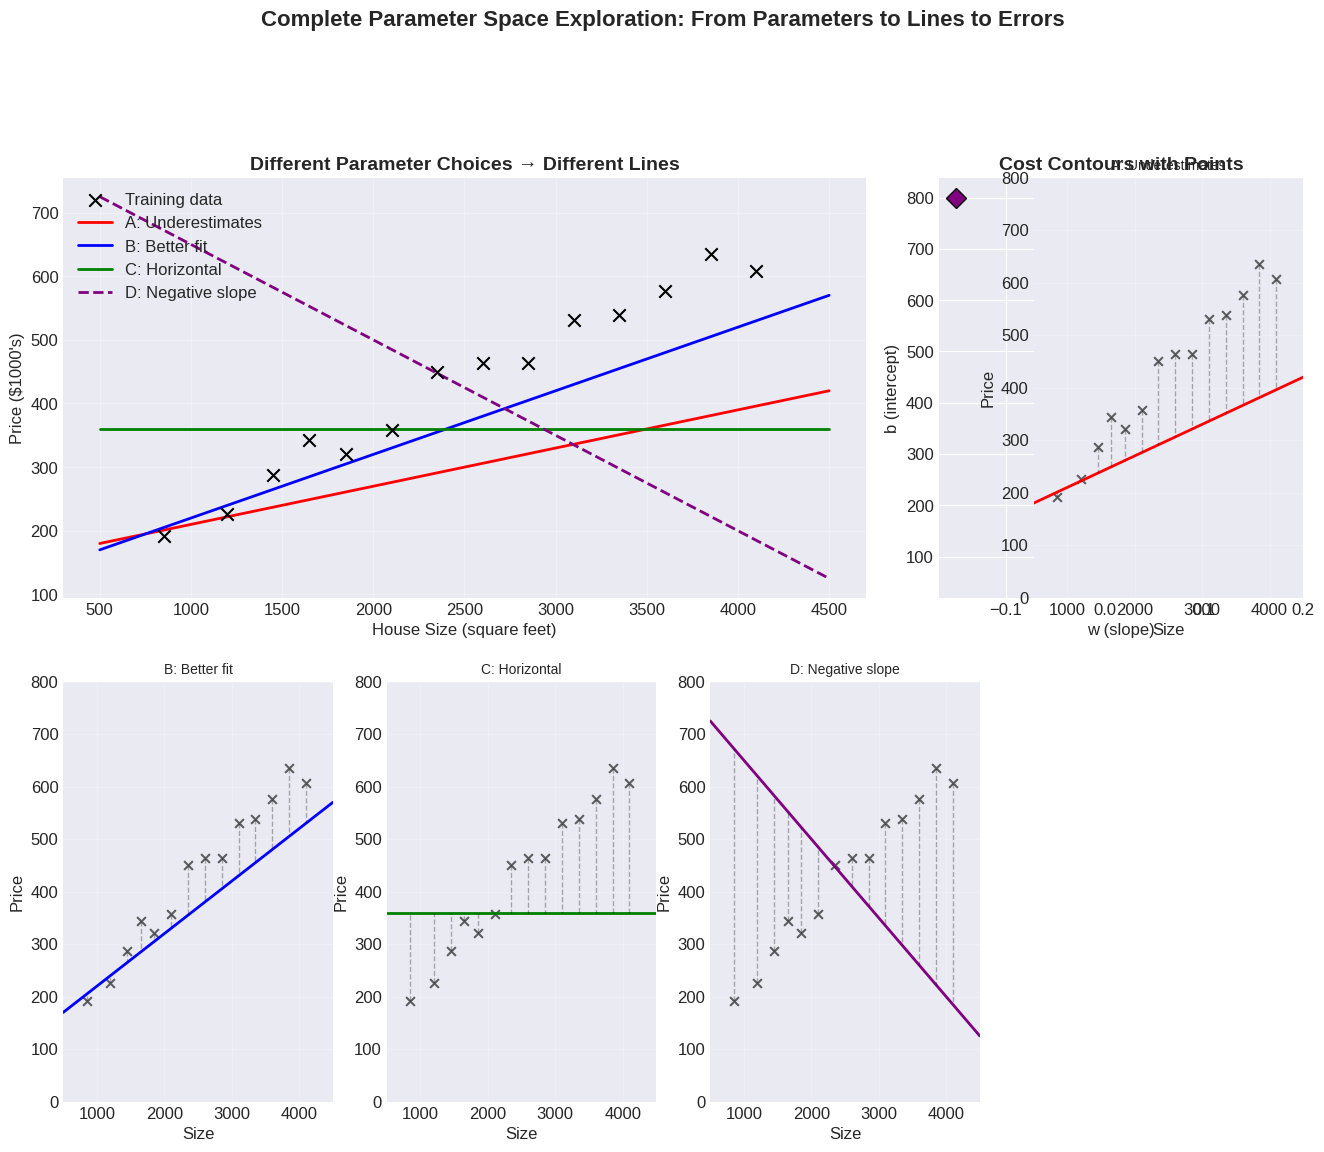

In [ ]:
# Comprehensive visualization: Parameter space vs. model space
fig = plt.figure(figsize=(16, 12))

# Define four parameter sets to explore
param_sets = [
    {'w': 0.06, 'b': 150, 'color': 'red', 'marker': 's', 'label': 'A: Underestimates'},
    {'w': 0.10, 'b': 120, 'color': 'blue', 'marker': 'o', 'label': 'B: Better fit'},
    {'w': 0.0, 'b': 360, 'color': 'green', 'marker': '^', 'label': 'C: Horizontal'},
    {'w': -0.15, 'b': 800, 'color': 'purple', 'marker': 'D', 'label': 'D: Negative slope'}
]

# Plot 1: Training data with all four lines
ax1 = plt.subplot(2, 3, (1, 2))
ax1.scatter(house_sizes, prices, color='black', marker='x', s=80, label='Training data', zorder=5)

x_line = np.linspace(500, 4500, 100)
for params in param_sets:
    y_line = params['w'] * x_line + params['b']
    ax1.plot(x_line, y_line, color=params['color'], linewidth=2,
             label=params['label'], linestyle='--' if params['w'] < 0 else '-')

ax1.set_xlabel('House Size (square feet)', fontsize=12)
ax1.set_ylabel('Price ($1000\'s)', fontsize=12)
ax1.set_title('Different Parameter Choices → Different Lines', fontweight='bold', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Plot 2: Contour plot with points
ax2 = plt.subplot(2, 3, 3)
contour = ax2.contour(W, B, J, levels=20, cmap='viridis', alpha=0.7)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('w (slope)', fontsize=12)
ax2.set_ylabel('b (intercept)', fontsize=12)
ax2.set_title('Cost Contours with Points', fontweight='bold', fontsize=14)

# Add parameter points
for params in param_sets:
    ax2.plot(params['w'], params['b'], marker=params['marker'],
             markersize=10, color=params['color'], markeredgecolor='black',
             markeredgewidth=1)

# Mark minimum
ax2.plot(w_min, b_min, 'r*', markersize=15, markeredgecolor='black',
         markeredgewidth=1, label='Minimum')

# Plot 3-6: Individual error visualizations
positions = [4, 5, 6, 7]  # 2x4 grid positions for subplots
for i, params in enumerate(param_sets):
    ax = plt.subplot(2, 4, positions[i])

    # Plot data and line
    ax.scatter(house_sizes, prices, color='black', marker='x', s=40, alpha=0.6)
    y_line = params['w'] * x_line + params['b']
    ax.plot(x_line, y_line, color=params['color'], linewidth=2)

    # Add error lines
    predictions = params['w'] * house_sizes + params['b']
    for j, (x, y_true, y_pred) in enumerate(zip(house_sizes, prices, predictions)):
        ax.plot([x, x], [y_true, y_pred], 'k--', alpha=0.3, linewidth=1)

    ax.set_xlabel('Size')
    ax.set_ylabel('Price')
    ax.set_title(f"{params['label']}", fontsize=10)
    ax.set_xlim(500, 4500)
    ax.set_ylim(0, 800)
    ax.grid(True, alpha=0.2)

plt.suptitle('Complete Parameter Space Exploration: From Parameters to Lines to Errors',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Code Examples

### 6.1 Implementing Linear Regression from Scratch

Here's a complete implementation of univariate linear regression, including the model, cost function, and visualization tools.

Best parameters found:
  w = 0.1357
  b = 88.98
  Minimum cost J = 257.24

Model: price = 0.1357 * size + 88.98


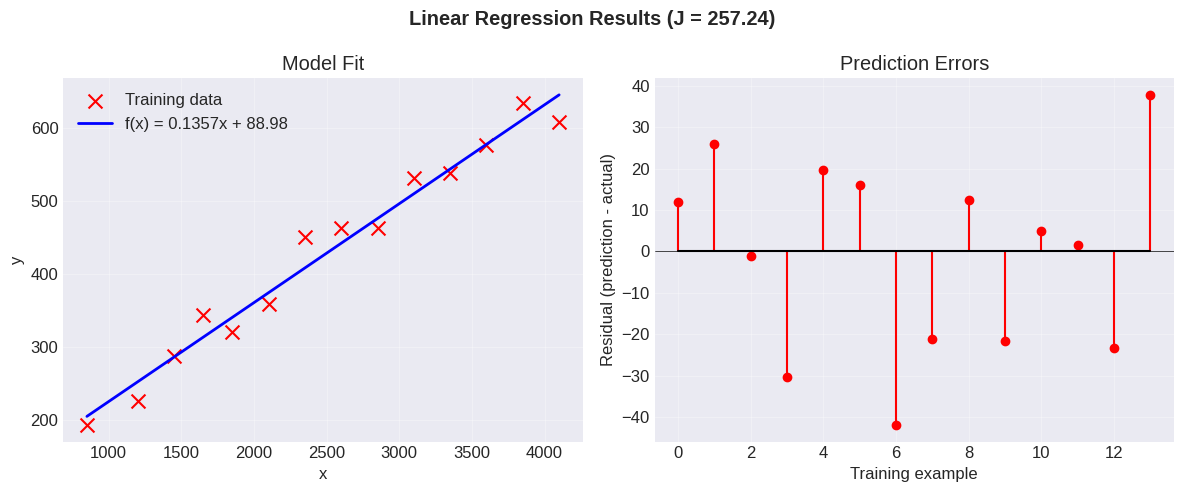


Prediction for 2500 sq ft house: $428K


In [ ]:
class UnivariateLinearRegression:
    """
    A from-scratch implementation of linear regression with one variable.
    """

    def __init__(self):
        self.w = None  # slope
        self.b = None  # intercept
        self.J_history = []  # track cost during training

    def predict(self, x):
        """Make predictions for input x"""
        return self.w * x + self.b

    def compute_cost(self, x, y, w, b):
        """
        Compute squared error cost J(w,b)

        Args:
            x: array of input features
            y: array of target values
            w, b: current parameter values

        Returns:
            J: cost value
        """
        m = len(x)
        predictions = w * x + b
        errors = predictions - y
        squared_errors = errors ** 2
        J = np.sum(squared_errors) / (2 * m)
        return J

    def fit_grid_search(self, x, y, w_range, b_range):
        """
        Find best parameters by exhaustive grid search
        (demonstrating the cost landscape concept)
        """
        J_grid = np.zeros((len(b_range), len(w_range)))

        for i, w_val in enumerate(w_range):
            for j, b_val in enumerate(b_range):
                J_grid[j, i] = self.compute_cost(x, y, w_val, b_val)

        # Find minimum
        min_idx = np.unravel_index(np.argmin(J_grid), J_grid.shape)
        self.w = w_range[min_idx[1]]
        self.b = b_range[min_idx[0]]
        self.J_min = J_grid[min_idx]

        return J_grid

    def visualize_fit(self, x, y):
        """Plot the data and fitted line"""
        plt.figure(figsize=(12, 5))

        # Data and line
        plt.subplot(1, 2, 1)
        plt.scatter(x, y, color='red', marker='x', s=100, label='Training data')
        x_line = np.linspace(min(x), max(x), 100)
        plt.plot(x_line, self.predict(x_line), 'b-', linewidth=2,
                label=f'f(x) = {self.w:.4f}x + {self.b:.2f}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Model Fit')
        plt.grid(True, alpha=0.3)
        plt.legend()

        # Residuals
        plt.subplot(1, 2, 2)
        predictions = self.predict(x)
        residuals = predictions - y
        plt.stem(range(len(x)), residuals, linefmt='r-', markerfmt='ro', basefmt='k-')
        plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        plt.xlabel('Training example')
        plt.ylabel('Residual (prediction - actual)')
        plt.title('Prediction Errors')
        plt.grid(True, alpha=0.3)

        plt.suptitle(f'Linear Regression Results (J = {self.compute_cost(x, y, self.w, self.b):.2f})',
                    fontweight='bold')
        plt.tight_layout()
        plt.show()

# Demonstrate the class
model = UnivariateLinearRegression()

# Define search ranges
w_range = np.linspace(0.05, 0.2, 50)
b_range = np.linspace(20, 150, 50)

# Find best parameters
J_grid = model.fit_grid_search(house_sizes, prices, w_range, b_range)

print(f"Best parameters found:")
print(f"  w = {model.w:.4f}")
print(f"  b = {model.b:.2f}")
print(f"  Minimum cost J = {model.J_min:.2f}")
print(f"\nModel: price = {model.w:.4f} * size + {model.b:.2f}")

# Visualize
model.visualize_fit(house_sizes, prices)

# Make a prediction for a new house
new_house = 2500
predicted_price = model.predict(new_house)
print(f"\nPrediction for {new_house} sq ft house: ${predicted_price:.0f}K")

## 7. Key Takeaways

1. **Linear regression models relationships with a straight line**: The model f(x) = wx + b captures the linear relationship between one input feature and a continuous output.

2. **Parameters define the line**: The slope (w) determines steepness; the intercept (b) determines where the line crosses the y-axis. Different parameter combinations produce completely different lines.

3. **The cost function measures fit quality**: J(w,b) averages squared errors between predictions and actual targets. Lower cost = better fit.

4. **The goal is minimization**: Find parameters w,b that make J(w,b) as small as possible - this yields the best-fit line.

5. **The cost landscape is convex**: J(w,b) forms a bowl-shaped surface with a single global minimum, making optimization tractable.

6. **Visualization is crucial for intuition**: 3D surfaces and contour plots reveal how parameter choices affect model performance and cost.

7. **Notation matters**: Standard notation (x, y, m, superscript indices) enables clear communication and scalable implementations.

8. **Squared errors serve multiple purposes**: They eliminate sign cancellation, penalize large errors more, and create a smooth differentiable function.

9. **The 1/(2m) scaling factor**: Dividing by m makes cost independent of dataset size; the extra 1/2 simplifies later calculus.

10. **Foundation for advanced models**: Understanding univariate linear regression prepares you for multivariate regression, polynomial regression, and neural networks.

## 8. Quick Revision

### Key Formulas

| Concept | Formula | Description |
|---------|---------|-------------|
| **Model** | $f_{w,b}(x) = wx + b$ | Linear prediction function |
| **Prediction** | $ŷ = f_{w,b}(x)$ | Estimated output |
| **Cost Function** | $J(w,b) = \frac{1}{2m}\sum_{i=1}^m (f_{w,b}(x^{(i)}) - y^{(i)})^2$ | Squared error cost |
| **Single Error** | $error^{(i)} = f_{w,b}(x^{(i)}) - y^{(i)}$ | Difference for one example |
| **Squared Error** | $(error^{(i)})^2$ | Squared difference |

### Essential Definitions

| Term | Definition |
|------|------------|
| **Training Set** | Collection of (x,y) pairs used to train the model |
| **Feature (x)** | Input variable (e.g., house size) |
| **Target (y)** | Output variable being predicted (e.g., price) |
| **m** | Number of training examples |
| **$(x^{(i)}, y^{(i)})$** | The i-th training example (superscript = index) |
| **Parameters** | w (slope) and b (intercept) - what the model learns |
| **Prediction (ŷ)** | Model's estimated output, pronounced "y-hat" |
| **Cost (J)** | Measures how well model fits data |
| **Squared Error** | (ŷ - y)², the building block of cost function |
| **Linear Regression** | Model that predicts continuous output using linear combination of inputs |
| **Univariate** | Having one input variable |

### Key Intuitions

1. **Each (w,b) pair** → One specific line → One cost value J(w,b)
2. **Small J** → Predictions close to targets → Good fit
3. **Large J** → Predictions far from targets → Poor fit
4. **Cost surface** is convex (bowl-shaped) → Only one minimum
5. **Contour plots** show lines of equal cost (like elevation maps)

### Common Mistakes to Avoid

| Mistake | Correct Approach |
|---------|------------------|
| Confusing ŷ (prediction) with y (actual) | ŷ comes from model; y is true value in training data |
| Treating superscript (i) as exponent | ($x^{(i)}$ means i-th example, not x to the i-th power) |
| Forgetting to divide by m in cost function | Always average, don't just sum |
| Using only one parameter to test intuition | Both w and b matter in full model |

## Practice Questions

1. **Notation**: If a training set has 100 examples, what does $x^{(52)}$ represent?
2. **Parameters**: If w = 0, what does the model $f(x)$ look like?
3. **Cost Function**: Why do we square the errors instead of just taking absolute values?
4. **Visualization**: In a contour plot of J(w,b), what does it mean when two points lie on the same contour line?
5. **Optimization**: Why is the convex shape of J(w,b) important for finding the best parameters?

**Answers:**
1. The input feature value for the 52nd training example
2. A horizontal line (constant function) at y = b
3. Squaring makes all errors positive (prevents cancellation), penalizes larger errors more, and creates a differentiable function
4. They have the same cost value J(w,b) even though parameters differ
5. Convexity guarantees only one global minimum, so optimization algorithms can reliably find it

## Next Steps

In the upcoming lectures, you'll learn:
- **Gradient Descent**: An algorithm to efficiently minimize J(w,b) without exhaustive search
- **Multivariate Linear Regression**: Extending to multiple input features
- **Feature Scaling**: Techniques to improve optimization performance
- **Polynomial Regression**: Fitting curves instead of straight lines
- **Learning Curves**: Diagnosing model performance

The concepts covered here - model representation, cost functions, and parameter optimization - are the foundation for all supervised learning algorithms you'll encounter throughout your machine learning journey.

INTERACTIVE PARAMETER EXPLORATION

Try different w and b values to see how the line and cost change.
Enter values to test, or type 'quit' to exit.


Enter w and b (space-separated) or 'quit': 3 5


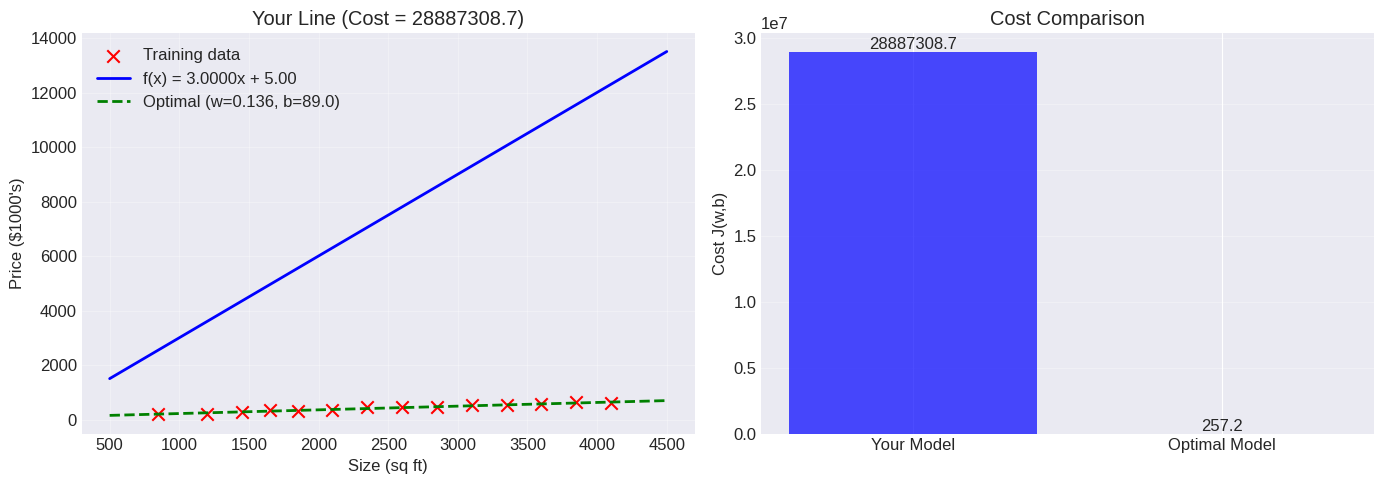

Your cost is 28887051.5 higher than optimal.
Keep trying to get closer!

Enter w and b (space-separated) or 'quit': 5 7


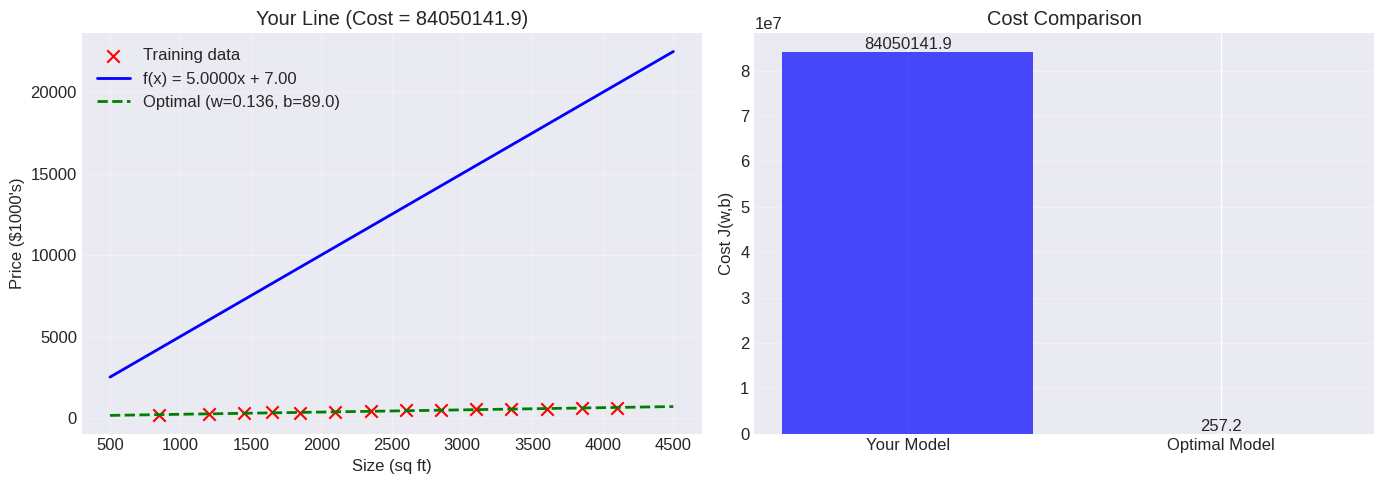

Your cost is 84049884.7 higher than optimal.
Keep trying to get closer!

Enter w and b (space-separated) or 'quit': quit


In [ ]:
# Final interactive demo: Explore parameter space yourself
print("=" * 60)
print("INTERACTIVE PARAMETER EXPLORATION")
print("=" * 60)
print("\nTry different w and b values to see how the line and cost change.")
print("Enter values to test, or type 'quit' to exit.\n")

# Get original cost at optimum
optimal_cost = model.compute_cost(house_sizes, prices, model.w, model.b)

while True:
    try:
        user_input = input("\nEnter w and b (space-separated) or 'quit': ")
        if user_input.lower() == 'quit':
            break

        w_test, b_test = map(float, user_input.split())

        # Compute cost
        cost_test = model.compute_cost(house_sizes, prices, w_test, b_test)

        # Visualize
        plt.figure(figsize=(14, 5))

        # Data and line
        plt.subplot(1, 2, 1)
        plt.scatter(house_sizes, prices, color='red', marker='x', s=80, label='Training data')
        x_line = np.linspace(500, 4500, 100)
        plt.plot(x_line, w_test * x_line + b_test, 'b-', linewidth=2,
                label=f'f(x) = {w_test:.4f}x + {b_test:.2f}')
        plt.plot(x_line, model.w * x_line + model.b, 'g--', linewidth=2,
                label=f'Optimal (w={model.w:.3f}, b={model.b:.1f})')
        plt.xlabel('Size (sq ft)')
        plt.ylabel('Price ($1000\'s)')
        plt.title(f'Your Line (Cost = {cost_test:.1f})')
        plt.grid(True, alpha=0.3)
        plt.legend()

        # Cost comparison
        plt.subplot(1, 2, 2)
        labels = ['Your Model', 'Optimal Model']
        costs = [cost_test, optimal_cost]
        colors = ['blue', 'green']
        bars = plt.bar(labels, costs, color=colors, alpha=0.7)
        plt.ylabel('Cost J(w,b)')
        plt.title('Cost Comparison')
        plt.grid(True, alpha=0.3, axis='y')

        # Add value labels
        for bar, cost in zip(bars, costs):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{cost:.1f}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        if cost_test < optimal_cost:
            print("IMPOSSIBLE! You found a better fit than the optimal solution?")
            print("(This shouldn't happen - check your calculations)")
        else:
            print(f"Your cost is {cost_test - optimal_cost:.1f} higher than optimal.")
            print("Keep trying to get closer!")

    except Exception as e:
        print(f"Error: {e}. Please enter two numbers separated by space.")

---
**Notebook Complete**

This notebook provides a comprehensive foundation in univariate linear regression. You should now understand:
- How to represent data and models in supervised learning
- The role and interpretation of parameters w and b
- How the cost function measures model performance
- Visual relationships between parameters, lines, and cost
- The optimization goal of minimizing J(w,b)

These concepts will be essential as you progress to more advanced machine learning topics.